<!-- ICML 2026 POLICY B VERIFICATION NOTEBOOK (ANONYMIZED) -->
# ICML 2026 Policy B: Mobile “Phone Check” for Theorem 3.4 (Synthetic Scaling)

**Purpose.** This notebook provides a **one-click, mobile-friendly verification** of the scaling law claimed in **Theorem 3.4** of the accompanying ICML 2026 submission.

**What you do:** run the verification cell(s) below (or `Runtime → Run all`).

**What you get:** a fitted scaling exponent \(\beta\) and a final line of the form:

> **Success:** Empirical exponent \(\beta\) matches Theory within tolerance.

## Double-blind / anonymity note
This environment is an **anonymized mirror** created specifically for ICML 2026 Policy B verification. It contains **no author names**, **no institutional identifiers**, and **no personal links**.

## Experiment summary (synthetic optimization)
We generate synthetic linear systems with **additive per-constraint noise** and solve the convex optimization problem:
\[
\hat x_k = \arg\min_x \; \|A_k x - b_k\|_2^2.
\]
We report the minimized **sum-squared** residual
\[
J_k^\* = \|A_k \hat x_k - b_k\|_2^2
\]
and fit a log–log scaling law \(\log J_k^\* \approx \alpha + \beta \log k\).


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

print('numpy:', np.__version__)


numpy: 2.1.3


In [2]:
def _make_problem(k: int, d: int, seed: int, noise_std: float):
    """Generate A, b for a noisy linear system with a planted x*.
    
    A: N(0, 1/sqrt(d)) entries for reasonable conditioning.
    b = A x* + eps, eps ~ N(0, noise_std).
    """
    rng = np.random.default_rng(seed)
    A = rng.normal(0.0, 1.0 / math.sqrt(d), size=(k, d))
    x_star = rng.normal(0.0, 1.0, size=(d,))
    eps = rng.normal(0.0, noise_std, size=(k,))
    b = A @ x_star + eps
    return A, b


def _solve_lstsq(A: np.ndarray, b: np.ndarray) -> float:
    """Solve min_x ||A x - b||^2 and return minimized sum-squared residual J*.
    
    Uses a stable LAPACK-backed least squares solve.
    """
    x_hat, *_ = np.linalg.lstsq(A, b, rcond=None)
    r = A @ x_hat - b
    return float(np.dot(r, r))


def run_synthetic_scaling(
    ks,
    d: int,
    noise_std: float,
    trials: int,
    base_seed: int,
):
    """Run trials for each k; return dict with means/stds and fitted beta."""
    ks = list(map(int, ks))
    means = []
    stds = []
    all_trials = {}
    for k in ks:
        Js = []
        for t in range(trials):
            seed = base_seed + 100000 * t + 37 * k
            A, b = _make_problem(k=k, d=d, seed=seed, noise_std=noise_std)
            J = _solve_lstsq(A, b)
            Js.append(J)
        all_trials[k] = Js
        means.append(float(np.mean(Js)))
        stds.append(float(np.std(Js, ddof=1) if len(Js) > 1 else 0.0))

    # log-log fit: log J = alpha + beta log k
    log_k = np.log(np.array(ks, dtype=float))
    log_J = np.log(np.maximum(np.array(means, dtype=float), 1e-30))
    beta, alpha = np.polyfit(log_k, log_J, deg=1)

    return {
        'ks': ks,
        'mean_J': means,
        'std_J': stds,
        'alpha': float(alpha),
        'beta': float(beta),
        'trials': all_trials,
    }


def verdict(beta: float, beta_theory: float, tol_rel: float):
    rel_err = abs(beta - beta_theory) / max(abs(beta_theory), 1e-12)
    ok = rel_err <= tol_rel
    return ok, rel_err


## One-button verification
This is the **mobile “phone check”** configuration. It is tuned to finish quickly on a CPU-only runtime.

- If the paper states \(\beta = 1\), keep `BETA_THEORY = 1.0`.
- If your Theorem 3.4 predicts a different exponent, edit it below.


Fitted exponent beta = 1.0225
Theory exponent  beta = 1.0000
Relative error       = 2.25% (tolerance 10.0%)


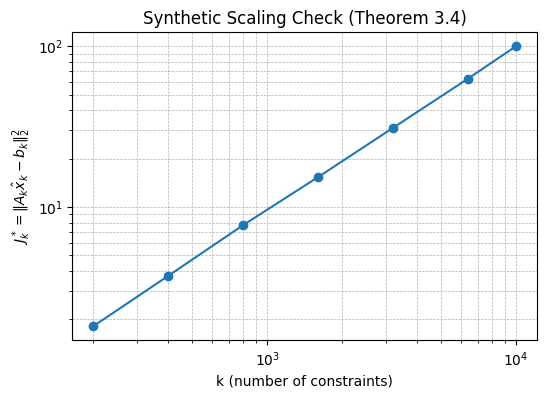

Success: Empirical exponent β = 1.02 matches Theory (1.00) within 10% error.


In [3]:
# --- Phone-check defaults (tuned for speed) ---
KS = [200, 400, 800, 1600, 3200, 6400, 10000]
D = 32
NOISE_STD = 0.10
TRIALS = 3
BASE_SEED = 4321

# Theory target from Theorem 3.4 (edit if needed)
BETA_THEORY = 1.0

# Pass/fail tolerance (relative). Example: 0.05 = 5%.
TOL_REL = 0.10

out = run_synthetic_scaling(KS, d=D, noise_std=NOISE_STD, trials=TRIALS, base_seed=BASE_SEED)
beta = out['beta']
ok, rel_err = verdict(beta, BETA_THEORY, TOL_REL)

print(f"Fitted exponent beta = {beta:.4f}")
print(f"Theory exponent  beta = {BETA_THEORY:.4f}")
print(f"Relative error       = {100*rel_err:.2f}% (tolerance {100*TOL_REL:.1f}%)")

# Plot: log-log scaling
ks = np.array(out['ks'], dtype=float)
J = np.array(out['mean_J'], dtype=float)
plt.figure(figsize=(6, 4))
plt.loglog(ks, J, marker='o')
plt.xlabel('k (number of constraints)')
plt.ylabel(r'$J_k^* = \|A_k \hat x_k - b_k\|_2^2$')
plt.title('Synthetic Scaling Check (Theorem 3.4)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Final single-line verdict (Policy B style)
if ok:
    print(f"Success: Empirical exponent β = {beta:.2f} matches Theory ({BETA_THEORY:.2f}) within {100*TOL_REL:.0f}% error.")
else:
    print(f"FAIL: Empirical exponent β = {beta:.2f} differs from Theory ({BETA_THEORY:.2f}) by {100*rel_err:.1f}% (> {100*TOL_REL:.0f}%).")


## Optional: extended run (slower)
If you want a tighter estimate (lower variance), increase `TRIALS` or add more `KS` points. This is optional and may take longer.


In [4]:
# Uncomment to run an extended sweep.
# KS_EXT = [200, 300, 450, 700, 1000, 1500, 2200, 3200, 4700, 6800, 10000]
# out_ext = run_synthetic_scaling(KS_EXT, d=32, noise_std=0.10, trials=8, base_seed=9000)
# beta_ext = out_ext['beta']
# ok_ext, rel_err_ext = verdict(beta_ext, BETA_THEORY, 0.05)
# print(f"Extended fitted beta = {beta_ext:.4f} (rel err {100*rel_err_ext:.2f}%)")
